In [2]:
# ===============================
# IMPORT REQUIRED LIBRARIES
# ===============================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Subset

import numpy as np
import os
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

In [3]:
# ===============================
# CONFIGURATION
# ===============================

device = torch.device("cpu")

BASE_PATH = r"C:\Recommendation_Engine"

DATA_PATH = os.path.join(BASE_PATH, "data")
MODEL_PATH = os.path.join(BASE_PATH, "models", "fashion_model.pth")
FEATURE_PATH = os.path.join(BASE_PATH, "features", "features.npy")
LABEL_PATH = os.path.join(BASE_PATH, "features", "labels.npy")

os.makedirs(os.path.join(BASE_PATH, "models"), exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, "features"), exist_ok=True)
os.makedirs(DATA_PATH, exist_ok=True)

num_classes = 10
epochs = 2
batch_size = 64

In [4]:
# ===============================
# DATA LOADING & PREPROCESSING
# ===============================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root=DATA_PATH,
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root=DATA_PATH,
    train=False,
    download=True,
    transform=transform
)

# Subset for CPU speed
train_dataset = Subset(train_dataset, range(8000))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [5]:
# ===============================
# MODEL SETUP (Pretrained ResNet18)
# ===============================

model = models.resnet18(pretrained=True)

# Freeze pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

c:\Recommendation_Engine\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Recommendation_Engine\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
# ===============================
# TRAIN MODEL (ONLY FIRST TIME)
# ===============================

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH))
    print("Model loaded. Skipping training.")

else:
    print("Training started...")
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")

    torch.save(model.state_dict(), MODEL_PATH)
    print("Model saved successfully.")

Model loaded. Skipping training.


In [7]:
# ===============================
# MODEL EVALUATION
# ===============================

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 81.25%


In [8]:
# ===============================
# FEATURE EXTRACTION
# ===============================

if os.path.exists(FEATURE_PATH):
    features = np.load(FEATURE_PATH)
    labels_all = np.load(LABEL_PATH)
    print("Features loaded.")

else:
    print("Extracting features...")

    feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
    feature_extractor.eval()

    features = []
    labels_all = []

    with torch.no_grad():
        for images, labels in train_loader:
            images = images.to(device)

            output = feature_extractor(images)
            output = output.view(output.size(0), -1)

            features.append(output.cpu().numpy())
            labels_all.append(labels.numpy())

    features = np.vstack(features)
    labels_all = np.hstack(labels_all)

    np.save(FEATURE_PATH, features)
    np.save(LABEL_PATH, labels_all)

    print("Features saved successfully.")

Features loaded.


In [9]:
# ===============================
# RECOMMENDATION FUNCTION
# ===============================

def recommend(index, top_k=5):
    query_feature = features[index].reshape(1, -1)
    similarities = cosine_similarity(query_feature, features)[0]
    similar_indices = np.argsort(similarities)[-top_k-1:-1]
    return similar_indices

In [10]:
sample_index = 10
recommended = recommend(sample_index)

print("Input index:", sample_index)
print("Recommended indices:", recommended)

Input index: 10
Recommended indices: [5279 4159 2672 4255 7204]


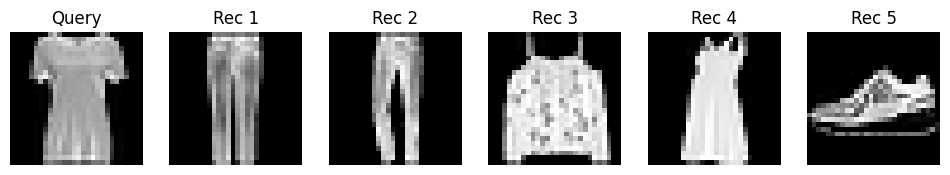

In [11]:
# ===============================
# VISUALIZE RECOMMENDATIONS
# ===============================

# Reload original dataset without subset for visualization
visual_dataset = torchvision.datasets.FashionMNIST(
    root=DATA_PATH,
    train=True,
    download=False,
    transform=transforms.ToTensor()
)

def show_recommendations(index):
    recommended = recommend(index)
    
    plt.figure(figsize=(12,4))
    
    # Show query image
    plt.subplot(1, 6, 1)
    plt.imshow(visual_dataset[index][0].squeeze(), cmap="gray")
    plt.title("Query")
    plt.axis("off")
    
    # Show recommended images
    for i, rec_index in enumerate(recommended):
        plt.subplot(1, 6, i+2)
        plt.imshow(visual_dataset[rec_index][0].squeeze(), cmap="gray")
        plt.title(f"Rec {i+1}")
        plt.axis("off")
    
    plt.show()

# Test visualization
show_recommendations(10)